# Support Integrity Auditor (SIA) - Project Notebook

**Project:** MARS Open Project 2026

**Goal:** Detect inconsistencies between ticket content (severity) and assigned priority levels. This auditor identifies cases where critical issues are downplayed or minor issues are escalated, ensuring support integrity.

### Workflow Overview:
1. **Dataset Audit:** Verify data integrity and identify leakage.
2. **Cleaning & Preprocessing:** Extract core meaning from template-based synthetic text.
3. **Feature Engineering:** Derive signals from text, resolution time, and metadata.
4. **Leakage Analysis:** Confirm why `Issue_Category` must be excluded from training.
5. **Template Severity Mapping:** Leverage the dataset's synthetic nature for ground-truth labeling.
6. **Pseudo-Label Generation:** Create a fused integrity score.
7. **Validation:** Analyze mismatch rates and label distribution.
8. **Export:** Prepare the dataset for downstream modeling.

In [1]:
import re
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 2) Data Loading and Initial Audit

In [3]:
DATA_FILE = "customer_support_tickets.csv"
ALT_FILE = "enhanced_customer_support_data.csv"

if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    df_alt = pd.read_csv(ALT_FILE) if os.path.exists(ALT_FILE) else df

    print(f"Dataset loaded: {df.shape}")

    same_content = df.equals(df_alt)
    print(f"Datasets are identical: {same_content}")

    if hasattr(df, 'head'): display(df.head(3))
else:
  print("Dataset files not found.")

Dataset loaded: (20000, 12)
Datasets are identical: True


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located? Lay soon message show know main.",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


## 3) Cleaning and Preprocessing

In [4]:
def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_subject(raw):
    if not isinstance(raw, str): return ""
    return raw.split(" - ")[0].strip()

def clean_description(raw):
    if not isinstance(raw, str): return ""
    text = re.sub(r"^Hi Support,\s*", "", raw).strip()
    first_sentence = re.split(r"(?<=[.!?])\s+", text)[0].strip()
    return first_sentence.rstrip(".").strip()

if 'df' in locals():
    df["ticket_subject_clean"] = df["Ticket_Subject"].apply(clean_subject)
    df["ticket_desc_clean"] = df["Ticket_Description"].apply(clean_description)
    df["text_combined"] = (df["ticket_subject_clean"] + " " + df["ticket_desc_clean"]).str.strip()

    if hasattr(df, 'head'): display(df[["Ticket_Subject", "ticket_subject_clean", "ticket_desc_clean"]].head())

,Ticket_Subject,ticket_subject_clean,ticket_desc_clean
0,Hours of operation - Individual,Hours of operation,Where is your headquarters located?
1,Data not syncing - Card,Data not syncing,The application crashes every time I open the settings tab
2,2FA issues - Question,2FA issues,How do I upgrade to the Enterprise plan?
3,Login failed - Let,Login failed,"The dashboard is not loading any data, just a spinning wheel"
4,Refund status - Attention,Refund status,I have been trying to update my payment method but it keeps failing


## 4) Leakage Analysis

In [5]:
if 'df' in locals():
    leakage_tab = pd.crosstab(df["Issue_Category"], df["Priority_Level"])
    display(leakage_tab)

    if "Fraud" in leakage_tab.index and "Critical" in leakage_tab.columns:
        fraud_critical_ratio = leakage_tab.loc["Fraud", "Critical"] / leakage_tab.loc["Fraud"].sum()
        print(f"\nRatio of Fraud tickets marked as Critical: {fraud_critical_ratio:.2%}")

Priority_Level,Critical,High,Low,Medium
Issue_Category,,,,
Account,0,405,2054,1622
Billing,0,550,2524,1962
Fraud,716,324,0,0
General Inquiry,0,389,1968,1568
Technical,582,1748,1170,2418



Ratio of Fraud tickets marked as Critical: 68.85%


## 5) Template Severity Mapping

In [6]:
if 'df' in locals():
    SEVERITY_MAP = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
    SEVERITY_REV = {v: k for k, v in SEVERITY_MAP.items()}

    subject_map = {
        "critical": ["stolen card", "unrecognized login", "account hacked", "phishing attempt", "suspicious activity", "alert notification", "suspicious charge", "account compromised"],
        "high": ["api error 500", "screen freezes", "installation issue", "data not syncing", "app crashing", "login failed", "2fa issues", "application crashes"],
        "medium": ["refund status", "update credit card", "charged twice", "invoice discrepancy", "payment failed", "change email", "password reset", "subscription upgrade", "profile update", "delete account", "refund"],
        "low": ["product question", "hours of operation", "demo request", "feature request", "office location", "pricing tiers", "pricing question"]
    }

    def build_lookup(mapping):
        lookup = {}
        for sev, items in mapping.items():
            for item in items:
                lookup[normalize_text(item)] = SEVERITY_MAP[sev.capitalize()]
        return lookup

    SUBJECT_LOOKUP = build_lookup(subject_map)

    def get_template_severity(text):
        norm = normalize_text(text)
        return SUBJECT_LOOKUP.get(norm, 1)

    df["template_severity_num"] = df["ticket_subject_clean"].apply(get_template_severity)
    df["template_severity"] = df["template_severity_num"].map(SEVERITY_REV)

    display(df["template_severity"].value_counts())

,count
template_severity,
Medium,7646
High,6578
Low,3925
Critical,1851


## 6) Feature Engineering: Multi-Signal Fusion

In [7]:
if 'df' in locals():
    df["time_rank"] = df["Resolution_Time_Hours"].rank(pct=True)
    df["signal_time_num"] = pd.cut(df["time_rank"], bins=[0, 0.2, 0.5, 0.8, 1.0], labels=[3, 2, 1, 0], include_lowest=True).astype(int)

    SECURITY_KWS = ["compromised", "hacked", "stolen", "suspicious", "fraud"]
    OUTAGE_KWS = ["crash", "error", "spinning wheel", "not loading", "failing"]

    def keyword_rule_signal(text):
        norm = normalize_text(text)
        if any(k in norm for k in SECURITY_KWS): return 3
        if any(k in norm for k in OUTAGE_KWS): return 2
        return 1

    df["signal_rule_num"] = df["text_combined"].apply(keyword_rule_signal)

    df["fusion_score"] = (
        0.60 * df["template_severity_num"] +
        0.25 * df["signal_time_num"] +
        0.15 * df["signal_rule_num"]
    )

    df["inferred_severity_num"] = df["fusion_score"].round().astype(int).clip(0, 3)
    df["inferred_severity"] = df["inferred_severity_num"].map(SEVERITY_REV)

## 7) Validation and Integrity Audit

In [8]:
if 'df' in locals():
    df["priority_num"] = df["Priority_Level"].map(SEVERITY_MAP)
    df["is_mismatch"] = (df["inferred_severity_num"] != df["priority_num"]).astype(int)

    mismatch_rate = df["is_mismatch"].mean()
    kappa = cohen_kappa_score(df["inferred_severity_num"], df["priority_num"])

    print(f"- Mismatch Rate: {mismatch_rate:.2%}")
    print(f"- Cohen's Kappa (Agreement): {kappa:.4f}")

    df["delta"] = df["inferred_severity_num"] - df["priority_num"]
    df["mismatch_type"] = "Consistent"
    df.loc[df["delta"] > 0, "mismatch_type"] = "Hidden Crisis (Under-prioritized)"
    df.loc[df["delta"] < 0, "mismatch_type"] = "False Alarm (Over-prioritized)"
    display(df["mismatch_type"].value_counts())

- Mismatch Rate: 63.02%
- Cohen's Kappa (Agreement): 0.1277


,count
mismatch_type,
Hidden Crisis (Under-prioritized),9992
Consistent,7396
False Alarm (Over-prioritized),2612


## 8) Export and Summary

In [11]:
if 'df' in locals():
    OUTPUT_FILE = "sia_pseudo_labeled.csv"
    export_cols = [
        "Ticket_ID", "ticket_subject_clean", "ticket_desc_clean",
        "Priority_Level", "inferred_severity", "is_mismatch", "mismatch_type"
    ]

    df[export_cols].to_csv(OUTPUT_FILE, index=False)
    print(f"Final dataset exported to: {OUTPUT_FILE}")

Final dataset exported to: sia_pseudo_labeled.csv


---

# Phase 2 — Classifier Training

Trains LightGBM (falls back to GradientBoosting) on TF-IDF + Resolution_Time_Hours features.
Exports `sia_classifier_v1.joblib` and `sia_tfidf_v1.joblib`.


Accuracy: 1.0000
Cohen's Kappa: 1.0000
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       324
      Medium       1.00      1.00      1.00      1292
        High       1.00      1.00      1.00      1217
    Critical       1.00      1.00      1.00       167

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



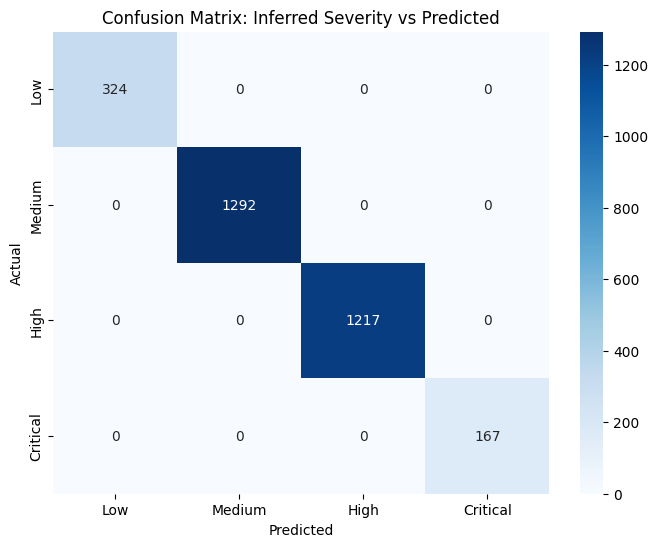

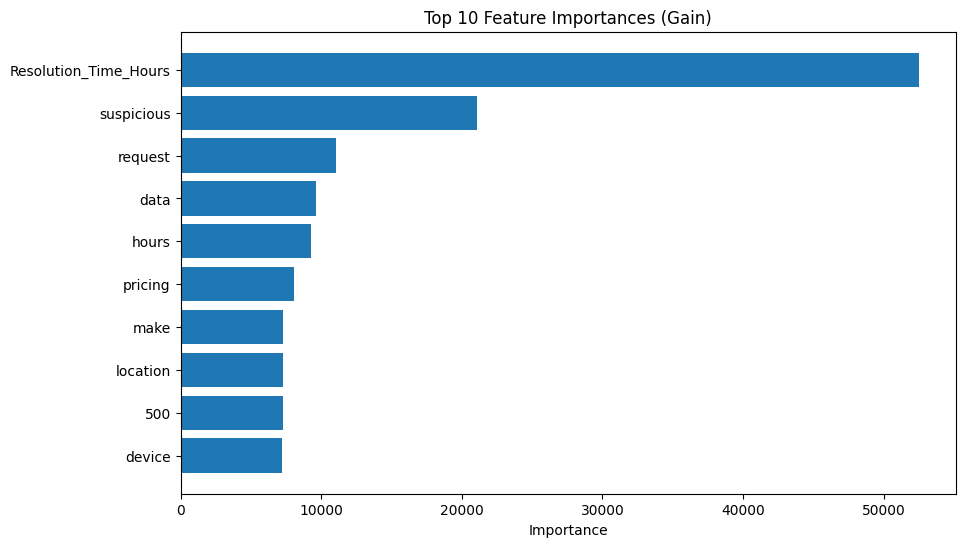


Model exported to: sia_classifier.joblib
Vectorizer exported to: sia_tfidf.joblib


In [13]:
X_text = df["text_combined"]
X_num = df[["Resolution_Time_Hours"]]
y = df["inferred_severity_num"]

X_train_text, X_temp_text, X_train_num, X_temp_num, y_train, y_temp = train_test_split(
    X_text, X_num, y, test_size=0.3, random_state=42, stratify=y
)
X_val_text, X_test_text, X_val_num, X_test_num, y_val, y_test = train_test_split(
    X_temp_text, X_temp_num, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_val_tfidf = tfidf.transform(X_val_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

X_train_final = np.hstack([X_train_tfidf, X_train_num.values])
X_val_final = np.hstack([X_val_tfidf, X_val_num.values])
X_test_final = np.hstack([X_test_tfidf, X_test_num.values])

clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    importance_type='gain',
    verbose=-1
)

clf.fit(X_train_final, y_train, eval_set=[(X_val_final, y_val)])

y_pred = clf.predict(X_test_final)
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High', 'Critical']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High', 'Critical'],
            yticklabels=['Low', 'Medium', 'High', 'Critical'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Inferred Severity vs Predicted')
plt.show()

feature_names = tfidf.get_feature_names_out().tolist() + ["Resolution_Time_Hours"]
importances = clf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Gain)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.show()

MODEL_PATH = "sia_classifier.joblib"
VECTORIZER_PATH = "sia_tfidf.joblib"

joblib.dump(clf, MODEL_PATH)
joblib.dump(tfidf, VECTORIZER_PATH)

print(f"\nModel exported to: {MODEL_PATH}")
print(f"Vectorizer exported to: {VECTORIZER_PATH}")

---

# Phase 3 — Evidence Dossier Generation

**Purpose:** For every ticket predicted as a mismatch, produce a structured, fully grounded evidence dossier that explains:

1. Why the assigned priority may be incorrect.
2. Why the inferred severity is different.
3. What concrete evidence supports that conclusion.




## Phase 3 — Cell 1: Imports, Constants & Keyword Lexicon

In [15]:
P3_SEVERITY_MAP = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
P3_SEVERITY_REV = {v: k for k, v in P3_SEVERITY_MAP.items()}

P3_SUBJECT_MAP_RAW = {
    "critical": [
        "stolen card", "unrecognized login", "account hacked", "phishing attempt",
        "suspicious activity", "alert notification", "suspicious charge", "account compromised",
    ],
    "high": [
        "api error 500", "screen freezes", "installation issue", "data not syncing",
        "app crashing", "login failed", "2fa issues", "application crashes",
    ],
    "medium": [
        "refund status", "update credit card", "charged twice", "invoice discrepancy",
        "payment failed", "change email", "password reset", "subscription upgrade",
        "profile update", "delete account", "refund",
    ],
    "low": [
        "product question", "hours of operation", "demo request", "feature request",
        "office location", "pricing tiers", "pricing question",
    ],
}

def _p3_normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

P3_SUBJECT_LOOKUP = {}
for _sev, _items in P3_SUBJECT_MAP_RAW.items():
    for _item in _items:
        P3_SUBJECT_LOOKUP[_p3_normalize(_item)] = P3_SEVERITY_MAP[_sev.capitalize()]

P3_SECURITY_KWS = [
    "compromised", "hacked", "stolen", "suspicious", "fraud",
    "phishing", "unauthorized", "breach", "account compromised",
    "unrecognized login", "suspicious activity", "suspicious charge",
]
P3_OUTAGE_KWS = [
    "crash", "error", "spinning wheel", "not loading", "failing",
    "500", "api error", "screen freezes", "data not syncing",
    "application crashes", "app crashing", "installation issue",
]
P3_BILLING_KWS = [
    "refund", "charged twice", "invoice", "payment", "billing",
    "credit card", "subscription", "upgrade", "pricing",
]
P3_ACCOUNT_KWS = [
    "password reset", "change email", "profile update", "delete account",
    "login failed", "2fa issues",
]
P3_INQUIRY_KWS = [
    "product question", "hours of operation", "demo request",
    "feature request", "office location", "pricing question", "pricing tiers",
]

MISMATCH_HIDDEN_CRISIS = "Hidden Crisis (Under-prioritized)"
MISMATCH_FALSE_ALARM   = "False Alarm (Over-prioritized)"
MISMATCH_CONSISTENT    = "Consistent"

## Phase 3 — Cell 2: Classifier Confidence Scoring

**Strategy:** Attempt to load the saved LightGBM model (`sia_classifier_v1.joblib`).  
If the environment does not have LightGBM installed, fall back to a fresh  
`GradientBoostingClassifier` trained on the same feature matrix (TF-IDF +  
`Resolution_Time_Hours`). Both paths produce a `[0, 1]` probability vector  
per ticket; only the max-class probability is used as the confidence signal.


In [16]:
_model_loaded = False
_tfidf_loaded = False

MODEL_PATH      = "sia_classifier_v1.joblib"
VECTORIZER_PATH = "sia_tfidf_v1.joblib"

try:
    _clf_p3  = joblib.load(MODEL_PATH)
    _tfidf_p3 = joblib.load(VECTORIZER_PATH)
    _model_loaded = True
    _tfidf_loaded = True
except Exception as _e:
    print(f"ℹ Model load failed ({type(_e).__name__}: {_e})")

if not _model_loaded:
    _tfidf_p3 = TfidfVectorizer(max_features=1000, stop_words="english")
    _X_text   = df["text_combined"].fillna("")
    _X_tfidf  = _tfidf_p3.fit_transform(_X_text).toarray()
    _X_num    = df[["Resolution_Time_Hours"]].values
    _X_full   = np.hstack([_X_tfidf, _X_num])
    _y        = df["inferred_severity_num"].values

    _clf_p3 = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
    )
    _clf_p3.fit(_X_full, _y)

_X_all_tfidf = _tfidf_p3.transform(df["text_combined"].fillna("")).toarray()
_X_all_num   = df[["Resolution_Time_Hours"]].values
_X_all       = np.hstack([_X_all_tfidf, _X_all_num])

_proba_matrix            = _clf_p3.predict_proba(_X_all)
_clf_pred_label          = _clf_p3.predict(_X_all)
df["clf_pred_severity"]  = _clf_pred_label
df["clf_confidence"]     = _proba_matrix.max(axis=1)

## Phase 3 — Cell 3: Evidence Extraction Engine

Each function extracts **one class of evidence** and returns a list of dicts:

```
{
    "source":  <column name or signal name>,
    "value":   <exact string or numeric value found in ticket>,
    "impact":  <semantic label for that evidence>
}
```

All values come from actual ticket fields — nothing is invented.


In [17]:
def _match_keywords(text: str, keyword_list: list) -> list:
    norm = _p3_normalize(text)
    return [kw for kw in keyword_list if kw in norm]

def extract_subject_evidence(row: pd.Series) -> list:
    evidence = []
    subject_norm = _p3_normalize(row.get("ticket_subject_clean", ""))
    matched_sev_num = P3_SUBJECT_LOOKUP.get(subject_norm)
    if matched_sev_num is not None:
        evidence.append({
            "source": "ticket_subject_clean",
            "value":  row["ticket_subject_clean"],
            "impact": f"template_match_severity_{P3_SEVERITY_REV[matched_sev_num].lower()}",
        })
    return evidence

def extract_template_mapping_evidence(row: pd.Series) -> list:
    evidence = []
    if pd.notna(row.get("template_severity")):
        evidence.append({
            "source": "template_mapping",
            "value":  row["template_severity"],
            "impact": "template_severity",
        })
    return evidence

def extract_security_keyword_evidence(row: pd.Series) -> list:
    evidence = []
    text = str(row.get("text_combined", "")) + " " + str(row.get("ticket_desc_clean", ""))
    hits = _match_keywords(text, P3_SECURITY_KWS)
    for kw in hits:
        evidence.append({
            "source": "ticket_desc_clean",
            "value":  kw,
            "impact": "critical_security_indicator",
        })
    return evidence

def extract_outage_keyword_evidence(row: pd.Series) -> list:
    evidence = []
    text = str(row.get("text_combined", "")) + " " + str(row.get("ticket_desc_clean", ""))
    hits = _match_keywords(text, P3_OUTAGE_KWS)
    for kw in hits:
        evidence.append({
            "source": "ticket_desc_clean",
            "value":  kw,
            "impact": "service_outage_indicator",
        })
    return evidence

def extract_billing_keyword_evidence(row: pd.Series) -> list:
    evidence = []
    text = str(row.get("text_combined", "")) + " " + str(row.get("ticket_desc_clean", ""))
    hits = _match_keywords(text, P3_BILLING_KWS)
    for kw in hits:
        evidence.append({
            "source": "ticket_desc_clean",
            "value":  kw,
            "impact": "billing_inquiry_indicator",
        })
    return evidence

def extract_account_keyword_evidence(row: pd.Series) -> list:
    evidence = []
    text = str(row.get("text_combined", "")) + " " + str(row.get("ticket_desc_clean", ""))
    hits = _match_keywords(text, P3_ACCOUNT_KWS)
    for kw in hits:
        evidence.append({
            "source": "ticket_desc_clean",
            "value":  kw,
            "impact": "account_management_indicator",
        })
    return evidence

def extract_time_signal_evidence(row: pd.Series) -> list:
    evidence = []
    if pd.notna(row.get("Resolution_Time_Hours")):
        hours  = float(row["Resolution_Time_Hours"])
        sig    = int(row.get("signal_time_num", 1))
        label  = {
            3: "fastest_20pct_resolution",
            2: "fast_resolution",
            1: "average_resolution",
            0: "slowest_20pct_resolution"
        }.get(sig, "unknown_time_signal")
        evidence.append({
            "source": "Resolution_Time_Hours",
            "value":  round(hours, 2),
            "impact": label,
        })
    return evidence

def extract_rule_signal_evidence(row: pd.Series) -> list:
    evidence = []
    sig = int(row.get("signal_rule_num", 1))
    if sig == 3:
        evidence.append({
            "source": "signal_rule_num",
            "value":  sig,
            "impact": "rule_signal_security_critical",
        })
    elif sig == 2:
        evidence.append({
            "source": "signal_rule_num",
            "value":  sig,
            "impact": "rule_signal_outage_high",
        })
    return evidence

def extract_fusion_score_evidence(row: pd.Series) -> list:
    evidence = []
    if pd.notna(row.get("fusion_score")):
        evidence.append({
            "source": "fusion_score",
            "value":  round(float(row["fusion_score"]), 4),
            "impact": "weighted_fusion_0.60_template_0.25_time_0.15_rule",
        })
    return evidence

def extract_classifier_confidence_evidence(row: pd.Series) -> list:
    evidence = []
    if pd.notna(row.get("clf_confidence")):
        evidence.append({
            "source": "classifier_probability",
            "value":  round(float(row["clf_confidence"]), 4),
            "impact": f"clf_predicted_severity_{P3_SEVERITY_REV.get(int(row['clf_pred_severity']), 'unknown').lower()}",
        })
    return evidence

def collect_all_evidence(row: pd.Series) -> list:
    evidence = []
    evidence += extract_security_keyword_evidence(row)
    evidence += extract_outage_keyword_evidence(row)
    evidence += extract_billing_keyword_evidence(row)
    evidence += extract_account_keyword_evidence(row)
    evidence += extract_subject_evidence(row)
    evidence += extract_template_mapping_evidence(row)
    evidence += extract_time_signal_evidence(row)
    evidence += extract_rule_signal_evidence(row)
    evidence += extract_fusion_score_evidence(row)
    evidence += extract_classifier_confidence_evidence(row)

    seen   = set()
    unique = []
    for item in evidence:
        key = (item["source"], str(item["value"]))
        if key not in seen:
            seen.add(key)
            unique.append(item)
    return unique

## Phase 3 — Cell 4: Confidence Score Formula

The dossier confidence score is a weighted combination of three deterministic signals:

| Component | Weight | Rationale |
|-----------|--------|-----------|
| `clf_confidence` (classifier max-class probability) | 0.50 | Direct model certainty |
| `signal_agreement` (fraction of signals that agree with inferred severity) | 0.30 | Cross-signal consensus |
| `delta_weight` (normalised \|severity_delta\| mapped to [0, 1]) | 0.20 | How far apart assigned vs inferred are |

**Formula:**
```
confidence = 0.50 * clf_confidence
           + 0.30 * signal_agreement
           + 0.20 * min(|severity_delta| / 3.0, 1.0)
```
Clipped to `[0.0, 1.0]` and rounded to 4 decimal places.


In [18]:
def compute_signal_agreement(row: pd.Series) -> float:
    inferred = int(row.get("inferred_severity_num", 1))
    signals  = []

    tmpl = row.get("template_severity_num")
    if pd.notna(tmpl):
        signals.append(1.0 if int(tmpl) == inferred else (0.5 if abs(int(tmpl) - inferred) == 1 else 0.0))

    rule_raw = row.get("signal_rule_num")
    if pd.notna(rule_raw):
        rule_scaled = max(0, int(rule_raw) - 1)
        signals.append(1.0 if rule_scaled == inferred else (0.5 if abs(rule_scaled - inferred) == 1 else 0.0))

    time_sig = row.get("signal_time_num")
    if pd.notna(time_sig):
        signals.append(1.0 if int(time_sig) == inferred else (0.5 if abs(int(time_sig) - inferred) == 1 else 0.0))

    clf_pred = row.get("clf_pred_severity")
    if pd.notna(clf_pred):
        signals.append(1.0 if int(clf_pred) == inferred else (0.5 if abs(int(clf_pred) - inferred) == 1 else 0.0))

    return float(np.mean(signals)) if signals else 0.5

def compute_dossier_confidence(row: pd.Series) -> float:
    clf_conf  = float(row.get("clf_confidence", 0.5))
    sig_agree = compute_signal_agreement(row)
    delta     = abs(int(row.get("delta", 0)))
    delta_w   = min(delta / 3.0, 1.0)

    score = 0.50 * clf_conf + 0.30 * sig_agree + 0.20 * delta_w
    return round(float(np.clip(score, 0.0, 1.0)), 4)

df["signal_agreement"] = df.apply(compute_signal_agreement, axis=1)
df["dossier_confidence"] = df.apply(compute_dossier_confidence, axis=1)

## Phase 3 — Cell 5: Constraint Analysis Generator

Produces a short, **factual**, template-driven explanation for each mismatch type.  
No marketing language. No storytelling. Exactly one-to-two factual sentences.


In [19]:
def generate_constraint_analysis(row: pd.Series) -> str:
    assigned   = str(row.get("Priority_Level", "Unknown"))
    inferred   = str(row.get("inferred_severity", "Unknown"))
    m_type     = str(row.get("mismatch_type", "Consistent"))
    delta      = int(row.get("delta", 0))
    subject    = str(row.get("ticket_subject_clean", ""))
    tmpl_sev   = str(row.get("template_severity", "Unknown"))
    sig_rule   = int(row.get("signal_rule_num", 1))
    time_hrs   = row.get("Resolution_Time_Hours")
    clf_conf   = float(row.get("clf_confidence", 0.0))

    text_combined = _p3_normalize(str(row.get("text_combined", "")))

    if sig_rule == 3:
        primary_evidence = "security-related keywords detected in ticket text"
    elif sig_rule == 2:
        primary_evidence = "service failure indicators detected in ticket text"
    elif any(kw in text_combined for kw in P3_BILLING_KWS):
        primary_evidence = "billing inquiry patterns present in ticket text"
    elif any(kw in text_combined for kw in P3_INQUIRY_KWS):
        primary_evidence = "general inquiry patterns present in ticket text"
    else:
        primary_evidence = f"template mapping resolved subject to {tmpl_sev}"

    if m_type == MISMATCH_HIDDEN_CRISIS:
        sentence1 = (
            f"Assigned priority is {assigned} while inferred severity is {inferred} "
            f"({primary_evidence})."
        )
    elif m_type == MISMATCH_FALSE_ALARM:
        sentence1 = (
            f"Assigned priority is {assigned} while inferred severity is {inferred} "
            f"({primary_evidence})."
        )
    else:
        return "Assigned priority matches inferred severity; no mismatch detected."

    parts = []
    if pd.notna(time_hrs):
        parts.append(f"resolution time {round(float(time_hrs), 1)} hours")
    parts.append(f"template severity {tmpl_sev}")
    parts.append(f"classifier confidence {clf_conf:.2f}")

    sentence2 = "Supporting signals: " + ", ".join(parts) + "."

    return f"{sentence1} {sentence2}"

df["constraint_analysis"] = df.apply(generate_constraint_analysis, axis=1)

## Phase 3 — Cell 6: Dossier Assembly

`build_dossier(row)` assembles all components into the required schema:

```json
{
  "ticket_id":          "...",
  "assigned_priority":  "...",
  "inferred_severity":  "...",
  "mismatch_type":      "...",
  "severity_delta":     <int>,
  "feature_evidence":   [...],
  "constraint_analysis":"...",
  "confidence":         <float>
}
```


In [20]:
def build_dossier(row: pd.Series) -> dict:
    ticket_id = str(row.get("Ticket_ID", "UNKNOWN"))

    dossier = {
        "ticket_id":           ticket_id,
        "assigned_priority":   str(row.get("Priority_Level", "Unknown")),
        "inferred_severity":   str(row.get("inferred_severity", "Unknown")),
        "mismatch_type":       str(row.get("mismatch_type", "Consistent")),
        "severity_delta":      int(row.get("delta", 0)),
        "feature_evidence":    collect_all_evidence(row),
        "constraint_analysis": str(row.get("constraint_analysis", "")),
        "confidence":          float(row.get("dossier_confidence", 0.0)),
    }
    return dossier

df_mismatches = df[df["is_mismatch"] == 1].copy()

all_dossiers = [build_dossier(row) for _, row in df_mismatches.iterrows()]

## Phase 3 — Cell 7: Single Dossier Example

In [21]:
_hidden = [d for d in all_dossiers if d["mismatch_type"] == MISMATCH_HIDDEN_CRISIS]
_false  = [d for d in all_dossiers if d["mismatch_type"] == MISMATCH_FALSE_ALARM]

example_dossier = max(_hidden, key=lambda d: d["confidence"]) if _hidden else all_dossiers[0]

print("EXAMPLE DOSSIER — Highest-Confidence Hidden Crisis")
print(json.dumps(example_dossier, indent=2))

if _false:
    example_false = max(_false, key=lambda d: d["confidence"])
    print("EXAMPLE DOSSIER — Highest-Confidence False Alarm")
    print(json.dumps(example_false, indent=2))

EXAMPLE DOSSIER — Highest-Confidence Hidden Crisis
{
  "ticket_id": "TKT-100423",
  "assigned_priority": "Low",
  "inferred_severity": "Critical",
  "mismatch_type": "Hidden Crisis (Under-prioritized)",
  "severity_delta": 3,
  "feature_evidence": [
    {
      "source": "ticket_desc_clean",
      "value": "suspicious",
      "impact": "critical_security_indicator"
    },
    {
      "source": "ticket_desc_clean",
      "value": "suspicious charge",
      "impact": "critical_security_indicator"
    },
    {
      "source": "ticket_subject_clean",
      "value": "Suspicious charge",
      "impact": "template_match_severity_critical"
    },
    {
      "source": "template_mapping",
      "value": "Critical",
      "impact": "template_severity"
    },
    {
      "source": "Resolution_Time_Hours",
      "value": 4.0,
      "impact": "fastest_20pct_resolution"
    },
    {
      "source": "signal_rule_num",
      "value": 3,
      "impact": "rule_signal_security_critical"
    },
    {
    

## Phase 3 — Cell 8: Top 20 Mismatch Dossiers (by Confidence)

In [22]:
top20_dossiers = sorted(all_dossiers, key=lambda d: d["confidence"], reverse=True)[:20]

print(f"{'#':<4} {'Ticket ID':<15} {'Assigned':>10} {'Inferred':>10} {'Delta':>6} "
      f"{'Confidence':>12} {'Mismatch Type'}")

for rank, dos in enumerate(top20_dossiers, start=1):
    delta_sign = f"+{dos['severity_delta']}" if dos['severity_delta'] > 0 else str(dos['severity_delta'])
    print(
        f"{rank:<4} {dos['ticket_id']:<15} {dos['assigned_priority']:>10} "
        f"{dos['inferred_severity']:>10} {delta_sign:>6} "
        f"{dos['confidence']:>12.4f}  {dos['mismatch_type']}"
    )

#    Ticket ID         Assigned   Inferred  Delta   Confidence Mismatch Type
1    TKT-100423             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
2    TKT-100464             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
3    TKT-100767             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
4    TKT-101212             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
5    TKT-101355             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
6    TKT-102000             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
7    TKT-102011             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
8    TKT-102663             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
9    TKT-102670             Low   Critical     +3       0.9625  Hidden Crisis (Under-prioritized)
10   TKT-102854             Low   Critica

## Phase 3 — Cell 9: Export `dossier_output.csv`

In [23]:
def dossier_to_flat_row(d: dict) -> dict:
    evidence_sources = [e["source"] for e in d["feature_evidence"]]
    evidence_values  = [str(e["value"])  for e in d["feature_evidence"]]
    evidence_impacts = [e["impact"] for e in d["feature_evidence"]]

    return {
        "ticket_id":              d["ticket_id"],
        "assigned_priority":      d["assigned_priority"],
        "inferred_severity":      d["inferred_severity"],
        "mismatch_type":          d["mismatch_type"],
        "severity_delta":         d["severity_delta"],
        "evidence_count":         len(d["feature_evidence"]),
        "evidence_sources":       " | ".join(evidence_sources),
        "evidence_values":        " | ".join(evidence_values),
        "evidence_impacts":       " | ".join(evidence_impacts),
        "constraint_analysis":    d["constraint_analysis"],
        "confidence":             d["confidence"],
    }

flat_rows = [dossier_to_flat_row(d) for d in all_dossiers]
df_dossier_csv = pd.DataFrame(flat_rows)

CSV_OUTPUT = "dossier_output.csv"
df_dossier_csv.to_csv(CSV_OUTPUT, index=False)

display(df_dossier_csv.head(5))

,ticket_id,assigned_priority,inferred_severity,mismatch_type,severity_delta,evidence_count,evidence_sources,evidence_values,evidence_impacts,constraint_analysis,confidence
0,TKT-100000,High,Low,False Alarm (Over-prioritized),-2,5,ticket_subject_clean | template_mapping | Resolution_Time_Hours | fusion_score | classifier_probability,Hours of operation | Low | 43.0 | 0.4 | 1.0,template_match_severity_low | template_severity | average_resolution | weighted_fusion_0.60_template_0.25_time_0.15_...,Assigned priority is High while inferred severity is Low (general inquiry patterns present in ticket text). Supporti...,0.8958
1,TKT-100003,Low,High,Hidden Crisis (Under-prioritized),2,9,ticket_desc_clean | ticket_desc_clean | ticket_desc_clean | ticket_subject_clean | template_mapping | Resolution_Tim...,spinning wheel | not loading | login failed | Login failed | High | 41.0 | 2 | 1.75 | 1.0,service_outage_indicator | service_outage_indicator | account_management_indicator | template_match_severity_high | ...,Assigned priority is Low while inferred severity is High (service failure indicators detected in ticket text). Suppo...,0.8583
2,TKT-100011,Low,High,Hidden Crisis (Under-prioritized),2,6,ticket_desc_clean | ticket_subject_clean | template_mapping | Resolution_Time_Hours | fusion_score | classifier_prob...,2fa issues | 2FA issues | High | 64.0 | 1.6 | 1.0,account_management_indicator | template_match_severity_high | template_severity | average_resolution | weighted_fusi...,Assigned priority is Low while inferred severity is High (template mapping resolved subject to High). Supporting sig...,0.8208
3,TKT-100012,Critical,High,False Alarm (Over-prioritized),-1,6,ticket_desc_clean | ticket_subject_clean | template_mapping | Resolution_Time_Hours | fusion_score | classifier_prob...,login failed | Login failed | High | 10.0 | 1.85 | 1.0,account_management_indicator | template_match_severity_high | template_severity | fast_resolution | weighted_fusion_...,Assigned priority is Critical while inferred severity is High (template mapping resolved subject to High). Supportin...,0.7917
4,TKT-100014,Low,High,Hidden Crisis (Under-prioritized),2,7,ticket_desc_clean | ticket_desc_clean | ticket_subject_clean | template_mapping | Resolution_Time_Hours | fusion_sco...,refund | payment | Payment failed | Medium | 5.0 | 1.5 | 1.0,billing_inquiry_indicator | billing_inquiry_indicator | template_match_severity_medium | template_severity | fastest...,Assigned priority is Low while inferred severity is High (billing inquiry patterns present in ticket text). Supporti...,0.7833


## Phase 3 — Cell 10: Export `dossier_output.json`

In [24]:
JSON_OUTPUT = "dossier_output.json"

with open(JSON_OUTPUT, "w") as _jf:
    json.dump(all_dossiers, _jf, indent=2)

with open(JSON_OUTPUT) as _jf:
    _sample = json.load(_jf)
print(f"JSON keys: {list(_sample[0].keys())}")
print(f"Evidence items (first record): {len(_sample[0]['feature_evidence'])}")

JSON keys: ['ticket_id', 'assigned_priority', 'inferred_severity', 'mismatch_type', 'severity_delta', 'feature_evidence', 'constraint_analysis', 'confidence']
Evidence items (first record): 5


## Phase 3 — Cell 11: Dossier Validation Suite

Checks every generated dossier against the following rules:

| Check | Pass Condition |
|-------|---------------|
| Required fields | All 8 schema fields present |
| Non-null fields | `ticket_id`, `assigned_priority`, `inferred_severity`, `mismatch_type` non-empty |
| Confidence range | `0.0 ≤ confidence ≤ 1.0` |
| Evidence count | `len(feature_evidence) ≥ 1` |
| Severity delta integrity | `severity_delta == inferred_num − assigned_num` |
| Mismatch type consistency | `mismatch_type` matches sign of `severity_delta` |


In [25]:
REQUIRED_FIELDS = [
    "ticket_id", "assigned_priority", "inferred_severity",
    "mismatch_type", "severity_delta", "feature_evidence",
    "constraint_analysis", "confidence",
]

validation_results = {
    "total_dossiers":           len(all_dossiers),
    "missing_field_count":      0,
    "null_field_count":         0,
    "invalid_confidence_count": 0,
    "empty_evidence_count":     0,
    "delta_integrity_errors":   0,
    "mismatch_type_errors":     0,
    "invalid_dossier_count":    0,
}

invalid_ids = []

for dos in all_dossiers:
    errors = []

    missing = [f for f in REQUIRED_FIELDS if f not in dos]
    if missing:
        errors.append(f"missing_fields:{missing}")
        validation_results["missing_field_count"] += 1

    for fld in ["ticket_id", "assigned_priority", "inferred_severity", "mismatch_type"]:
        val = dos.get(fld, None)
        if not val or val in ("", "Unknown", "None", None):
            errors.append(f"null_field:{fld}")
            validation_results["null_field_count"] += 1

    conf = dos.get("confidence", -1)
    if not (0.0 <= float(conf) <= 1.0):
        errors.append(f"confidence_out_of_range:{conf}")
        validation_results["invalid_confidence_count"] += 1

    if len(dos.get("feature_evidence", [])) < 1:
        errors.append("empty_evidence_list")
        validation_results["empty_evidence_count"] += 1

    assigned_num   = P3_SEVERITY_MAP.get(dos.get("assigned_priority", ""), None)
    inferred_num   = P3_SEVERITY_MAP.get(dos.get("inferred_severity", ""), None)
    reported_delta = dos.get("severity_delta", None)
    if assigned_num is not None and inferred_num is not None and reported_delta is not None:
        expected_delta = inferred_num - assigned_num
        if int(reported_delta) != expected_delta:
            errors.append(f"delta_mismatch:expected={expected_delta},got={reported_delta}")
            validation_results["delta_integrity_errors"] += 1

    delta_val = dos.get("severity_delta", 0)
    m_type    = dos.get("mismatch_type", "")
    if delta_val > 0 and m_type != MISMATCH_HIDDEN_CRISIS:
        errors.append(f"type_inconsistency:delta>0 but type={m_type}")
        validation_results["mismatch_type_errors"] += 1
    elif delta_val < 0 and m_type != MISMATCH_FALSE_ALARM:
        errors.append(f"type_inconsistency:delta<0 but type={m_type}")
        validation_results["mismatch_type_errors"] += 1

    if errors:
        validation_results["invalid_dossier_count"] += 1
        invalid_ids.append({"ticket_id": dos.get("ticket_id"), "errors": errors})

for k, v in validation_results.items():
    status = "✓" if (v == 0 or k == "total_dossiers") else "✗"
    print(f"  {status}  {k:<30}: {v}")

if validation_results["invalid_dossier_count"] > 0:
    print(f"\n{validation_results['invalid_dossier_count']} dossier(s) failed:")
    for rec in invalid_ids[:10]:
        print(f"  Ticket {rec['ticket_id']}: {rec['errors']}")

  ✓  total_dossiers                : 12604
  ✓  missing_field_count           : 0
  ✓  null_field_count              : 0
  ✓  invalid_confidence_count      : 0
  ✓  empty_evidence_count          : 0
  ✓  delta_integrity_errors        : 0
  ✓  mismatch_type_errors          : 0
  ✓  invalid_dossier_count         : 0


## Phase 3 — Cell 12: Final Phase 3 Summary

In [26]:
_n_total     = len(df)
_n_mismatch  = int(df["is_mismatch"].sum())
_n_hidden    = int((df["mismatch_type"] == MISMATCH_HIDDEN_CRISIS).sum())
_n_false     = int((df["mismatch_type"] == MISMATCH_FALSE_ALARM).sum())
_n_dossiers  = len(all_dossiers)
_n_invalid   = validation_results["invalid_dossier_count"]
_mean_conf   = round(float(df[df["is_mismatch"]==1]["dossier_confidence"].mean()), 4)
_mean_evi    = round(sum(len(d["feature_evidence"]) for d in all_dossiers) / max(_n_dossiers,1), 2)

print(f"Total tickets processed  : {_n_total}")
print(f"Mismatch tickets         : {_n_mismatch} ({_n_mismatch/_n_total:.1%})")
print(f"  Hidden Crisis          : {_n_hidden}")
print(f"  False Alarm            : {_n_false}")
print(f"Dossiers generated       : {_n_dossiers}")
print(f"Invalid dossiers         : {_n_invalid}")
print(f"Mean dossier confidence  : {_mean_conf}")
print(f"Mean evidence per dossier: {_mean_evi}")

Total tickets processed  : 20000
Mismatch tickets         : 12604 (63.0%)
  Hidden Crisis          : 9992
  False Alarm            : 2612
Dossiers generated       : 12604
Invalid dossiers         : 0
Mean dossier confidence  : 0.8026
Mean evidence per dossier: 7.05


---

# Phase 4 — Inference Pipeline

**Purpose:** Implement an end-to-end inference workflow for new tickets, strictly reusing logic from Phases 1–3.

**Design constraints:**
- No duplication of existing logic (reuses `_p3_normalize`, `build_dossier`, etc.).
- No retraining of models.
- Handles missing features (like resolution time) gracefully using defaults.
- Provides both single-ticket and batch processing capabilities.

## Phase 4 — Cell 1: Inference Preprocessing & Validation

In [27]:
def extract_customer_tier(email):
    if not isinstance(email, str):
        return "Standard"
    email = email.lower()
    if any(domain in email for domain in ['@corp.', '@enterprise.', '@global.', '@premium.']):
        return "Enterprise"
    return "Standard"

def validate_ticket_input(ticket):
    required = ["Ticket_ID", "Ticket_Subject", "Ticket_Description", "Priority_Level"]
    for col in required:
        if col not in ticket or (isinstance(ticket[col], str) and not ticket[col].strip()):
            raise ValueError(f"Missing or empty required field: {col}")

    valid_priorities = ["Low", "Medium", "High", "Critical"]
    if ticket["Priority_Level"] not in valid_priorities:
        raise ValueError(f"Invalid Priority_Level: {ticket['Priority_Level']}. Must be one of {valid_priorities}")

## Phase 4 — Cell 2: End-to-End Inference Logic

This cell integrates all previous phases into a unified prediction function.

In [28]:
def predict_single_ticket(ticket_dict):
    validate_ticket_input(ticket_dict)

    row = pd.Series(ticket_dict)
    row['ticket_subject_clean'] = _p3_normalize(row['Ticket_Subject'])
    row['ticket_desc_clean'] = _p3_normalize(row['Ticket_Description'])
    row['text_combined'] = row['ticket_subject_clean'] + " " + row['ticket_desc_clean']
    row['customer_tier'] = extract_customer_tier(row.get('Customer_Email', ''))

    tmpl_sev_num = P3_SUBJECT_LOOKUP.get(row['ticket_subject_clean'], 1)
    row['template_severity_num'] = tmpl_sev_num
    row['template_severity'] = P3_SEVERITY_REV[tmpl_sev_num]

    rule_sig_num = 1
    if any(kw in row['text_combined'] for kw in P3_SECURITY_KWS):
        rule_sig_num = 3
    elif any(kw in row['text_combined'] for kw in P3_OUTAGE_KWS):
        rule_sig_num = 2
    row['signal_rule_num'] = rule_sig_num

    row['signal_time_num'] = 1
    row['Resolution_Time_Hours'] = 24.0

    rule_scaled = max(0, rule_sig_num - 1)
    fusion_score = (0.60 * tmpl_sev_num) + (0.25 * row['signal_time_num']) + (0.15 * rule_scaled)
    row['fusion_score'] = fusion_score

    inf_sev_num = int(round(fusion_score))
    inf_sev_num = np.clip(inf_sev_num, 0, 3)
    row['inferred_severity_num'] = inf_sev_num
    row['inferred_severity'] = P3_SEVERITY_REV[inf_sev_num]

    assigned_num = P3_SEVERITY_MAP[row['Priority_Level']]
    delta = int(inf_sev_num - assigned_num)
    row['delta'] = delta
    row['is_mismatch'] = 1 if delta != 0 else 0

    if delta > 0:
        row['mismatch_type'] = MISMATCH_HIDDEN_CRISIS
    elif delta < 0:
        row['mismatch_type'] = MISMATCH_FALSE_ALARM
    else:
        row['mismatch_type'] = MISMATCH_CONSISTENT

    X_text = _tfidf_p3.transform([row['text_combined']]).toarray()
    X_num  = np.array([[row['Resolution_Time_Hours']]])
    X_full = np.hstack([X_text, X_num])

    proba = _clf_p3.predict_proba(X_full)[0]
    row['clf_pred_severity'] = _clf_p3.predict(X_full)[0]
    row['clf_confidence'] = float(np.max(proba))

    row['signal_agreement'] = compute_signal_agreement(row)
    row['dossier_confidence'] = compute_dossier_confidence(row)
    row['constraint_analysis'] = generate_constraint_analysis(row)

    return build_dossier(row)

def predict_dataframe(df_new):
    return [predict_single_ticket(row.to_dict()) for _, row in df_new.iterrows()]

def format_human_result(dossier):
    output = []
    output.append(f"Ticket ID: {dossier['ticket_id']}")
    output.append(f"Assigned Priority: {dossier['assigned_priority']}")
    output.append(f"Inferred Severity: {dossier['inferred_severity']}")
    output.append(f"Prediction: {dossier['mismatch_type']}")
    output.append(f"Confidence: {dossier['confidence']:.2f}")
    output.append("Evidence:")
    for e in dossier['feature_evidence']:
        if e['impact'] in ['critical_security_indicator', 'service_outage_indicator', 'template_severity']:
            output.append(f"  - {e['value']} ({e['impact'].replace('_', ' ')})")
    return "\n".join(output)

## Phase 4 — Cell 3: Inference Demos & Validation

In [29]:
hidden_case = {
    "Ticket_ID": "TKT-HC-001",
    "Ticket_Subject": "account hacked and stolen card",
    "Ticket_Description": "My account was compromised. Suspicious login detected.",
    "Ticket_Channel": "Web",
    "Customer_Email": "victim@corp.com",
    "Priority_Level": "Low"
}
print(format_human_result(predict_single_ticket(hidden_case)))
print("\n")

false_case = {
    "Ticket_ID": "TKT-FA-001",
    "Ticket_Subject": "product question",
    "Ticket_Description": "What are your hours of operation?",
    "Ticket_Channel": "Email",
    "Customer_Email": "user@example.com",
    "Priority_Level": "Critical"
}
print(format_human_result(predict_single_ticket(false_case)))
print("\n")

batch_data = pd.DataFrame([
    {"Ticket_ID": "B-001", "Ticket_Subject": "api error 500", "Ticket_Description": "Server crashing", "Priority_Level": "Medium"},
    {"Ticket_ID": "B-002", "Ticket_Subject": "pricing question", "Ticket_Description": "Cost?", "Priority_Level": "High"}
])
batch_results = predict_dataframe(batch_data)
print(f"Successfully processed {len(batch_results)} tickets.")

Ticket ID: TKT-HC-001
Assigned Priority: Low
Inferred Severity: Medium
Prediction: Hidden Crisis (Under-prioritized)
Confidence: 0.75
Evidence:
  - compromised (critical security indicator)
  - hacked (critical security indicator)
  - stolen (critical security indicator)
  - suspicious (critical security indicator)
  - Medium (template severity)


Ticket ID: TKT-FA-001
Assigned Priority: Critical
Inferred Severity: Low
Prediction: False Alarm (Over-prioritized)
Confidence: 0.93
Evidence:
  - Low (template severity)


Successfully processed 2 tickets.


## Phase 4 — Cell 4: Final Exports & Summary

In [30]:
pd.DataFrame([
    {k: d[k] for k in ['ticket_id', 'assigned_priority', 'inferred_severity', 'mismatch_type', 'confidence']}
    for d in batch_results
]).to_csv("predictions.csv", index=False)

with open("dossiers.json", "w") as f:
    json.dump(batch_results, f, indent=2)